In [31]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
from astropy.constants import G, c
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from disktab import AGNDisk


- M = 10⁸ M☉ (SMBH mass)
- α_d = 1 (Shakura-Sunyaev viscosity parameter)
- λ_d = 1 (Eddington ratio: Ṁ = λ_d Ṁ_Edd)
- Q_d = 1 (Toomre parameter, assumed constant)
- η_d = 0.1 (radiative efficiency: Ṁ_Edd = L_Edd / η_d c²)

*"The parameters λ_d, α_d, and Q_d are assumed to be constant values set to 1."*


In [32]:
M        = 1e8 * u.Msun   # SMBH mass
lambda_d = 1.0             # Eddington ratio
alpha_d  = 0.99            # viscosity parameter
eta_d    = 0.1             # radiative efficiency

# Eddington luminosity and accretion rate
L_edd    = 1.26e38 * (M / u.Msun) * u.erg / u.s
Mdot_edd = L_edd / (eta_d * c * c)
Mdot     = lambda_d * Mdot_edd

print(f"M     = {M}")
print(f"alpha = {alpha_d}")
print(f"Mdot  = {Mdot.to(u.kg/u.s):.4e}")

# ── Build disk ────────────────────────────────────────────────────────────────
disk_alpha       = AGNDisk()
disk_alpha.M     = M
disk_alpha.alpha = alpha_d
disk_alpha.Mdot  = Mdot

df_alpha = disk_alpha.spacehub_pretab(rvals=np.logspace(1, 9, 2000))
df_alpha.head()

M     = 100000000.0 solMass
alpha = 0.99
Mdot  = 1.4019e+23 kg / s


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,grad_T,grad_Sigma,grad_P,zone
0,9.870629,10.000000,209687.662225,0.000004,0.925331,486.472539,1.508607,726.557043,0.000012,4.271447e+09,0.375,0.194670,1.500010,Standard
1,9.962006,10.092575,208964.314919,0.000004,0.912628,487.345991,1.532351,739.317277,0.000012,4.227953e+09,0.375,0.177835,1.500010,Standard
2,10.054230,10.186008,208243.462903,0.000004,0.900100,488.069556,1.555986,751.834928,0.000012,4.182306e+09,0.375,0.144747,1.500009,Standard
3,10.147307,10.280305,207525.097567,0.000004,0.887744,488.647809,1.579512,764.106641,0.000012,4.134674e+09,0.375,0.112796,1.500008,Standard
4,10.241247,10.375475,206809.210335,0.000004,0.875558,489.085217,1.602929,776.129403,0.000012,4.085220e+09,0.375,0.081923,1.500007,Standard


In [33]:
alpha_csv = "../../SpaceHub/src/interaction/disk_tab/disk_stae321_alpha.csv"

# Uncomment to write:
# df_alpha.to_csv(alpha_csv, index=False)
# print(f"Wrote {len(df_alpha)} rows to {alpha_csv}")

Sirko-Goodman (SG) Disk

- M = 10⁸ M☉
- α = 0.01 (inner-region viscosity; outer SG regime ≈ α-disk with α=0.01 per paper)
- le = 1.0 (L/L_Edd, Eddington luminosity ratio)
- eps = 0.1 (radiative efficiency)
- N = 5000 (radial grid points)


- Uses tabulated OPAL opacities (Semenov 2003 + Badnell 2005) instead of Kramers

- Uses uniform slab convention instead of Gaussian vertical structure


In [34]:
import io
from contextlib import redirect_stdout
from pagn import Sirko
import pagn.constants as ct

# ── Section 3.1.2 parameters ─────────────────────────────────────────────────
M_msun = 1e8
alpha_sg = 0.01
le       = 1.0
eps      = 0.1
N        = 5000

# Solve disk (suppress pagn's verbose per-step output; show summary)
buf = io.StringIO()
with redirect_stdout(buf):
    sk = Sirko.SirkoAGN(Mbh=M_msun * ct.MSun, alpha=alpha_sg, le=le, eps=eps)
    sk.solve_disk(N=N)
print(buf.getvalue())

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 2.596689e+00 MSun/yr
le = 1.0
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.01
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Q<1 at i=1751 (R=9.07e+02 Rs)
Beginning star formation at index 1751
Mdisk = 422375337.90807015 Msun
Mdisk/Mbh = 4.223753379080701



In [35]:
# OUTPUT UNITS:
# ── SpaceHub internal units ────────────────────────────────────────────────────
# All quantities below are converted to SpaceHub's natural units:
#   - Length: AU
#   - Mass: M☉
#   - Time: T_unit = year/(2π) ≈ 0.159 years
#   - Velocity: AU/T_unit
#   - Viscosity: AU²/T_unit
#   - Pressure: M☉/(AU·T_unit²)
#   - Density: M☉/AU³
#   - Surface Density: M☉/AU²
#   - Temperature: K (unchanged)

# ── Unit conversion constants (must match disktab.py spacehub_pretab()) ───────
AU_m    = 1.495978707e11          # m per AU
Msun_kg = 1.98847e30              # kg per M☉
year_s  = 365.25636042 * 24 * 3600
T_unit  = year_s / (2 * np.pi)   # SpaceHub time unit [s]

CONV_LENGTH          = 1 / AU_m
CONV_DENSITY         = AU_m**3 / Msun_kg
CONV_PRESSURE        = AU_m * T_unit**2 / Msun_kg
CONV_VELOCITY        = T_unit / AU_m
CONV_VISCOSITY       = T_unit / AU_m**2
CONV_SURFACE_DENSITY = AU_m**2 / Msun_kg

# ── Extract pagn quantities (SI) ─────────────────────────────────────────────
Rg_si    = ct.G * (M_msun * ct.MSun) / ct.c**2
R        = sk.R          # [m]
R_Rg     = R / Rg_si
Tc       = sk.T          # [K]
rho      = sk.rho        # [kg/m³]
cs_si    = sk.cs         # [m/s]
H_si     = sk.h          # [m]
Q        = sk.Q          # dimensionless

P_si     = rho * cs_si**2          # [Pa]   — cs² = P_total/rho in pagn
visc_si  = alpha_sg * cs_si * H_si # [m²/s]
Sigma_si = 2 * rho * H_si          # [kg/m²] — slab convention

# ── Zone labels ───────────────────────────────────────────────────────────────
isf  = sk.isf  # index where Q < 1 first occurs; -1 if never
zone = np.array(["Standard"] * len(R))
if isf > 0:
    zone[isf:] = "Self-Reg"
print(f"isf={isf}  (Standard: {(zone=='Standard').sum()} pts, Self-Reg: {(zone=='Self-Reg').sum()} pts)")

# ── Log gradients, computed zone-by-zone to avoid boundary artifacts ──────────
def log_gradient(y, x):
    """Compute -d(ln y)/d(ln x) using central differences."""
    return -np.gradient(np.log(y), np.log(x))

grad_T     = np.zeros_like(R)
grad_Sigma = np.zeros_like(R)
grad_P     = np.zeros_like(R)

if isf > 0 and isf < len(R) - 1:
    for sl in (slice(0, isf), slice(isf, None)):
        grad_T[sl]     = log_gradient(Tc[sl],    R[sl])
        grad_Sigma[sl] = log_gradient(Sigma_si[sl], R[sl])
        grad_P[sl]     = log_gradient(P_si[sl],  R[sl])
else:
    grad_T     = log_gradient(Tc,       R)
    grad_Sigma = log_gradient(Sigma_si, R)
    grad_P     = log_gradient(P_si,     R)

# ── Build DataFrame in SpaceHub units ─────────────────────────────────────────
# DataFrame Columns (SpaceHub units):
#   R          — Orbital radius [AU]
#   R/Rg       — Radius in gravitational radii [dimensionless]
#   Tc         — Midplane temperature [K]
#   rho        — Midplane density [M☉/AU³]
#   P          — Midplane pressure [M☉/(AU·T_unit²)]
#   cs         — Sound speed [AU/T_unit]
#   H          — Scale height [AU]
#   visc       — Kinematic viscosity [AU²/T_unit]
#   Sigma      — Surface density [M☉/AU²]
#   Q          — Toomre stability parameter [dimensionless]
#   grad_T     — Temperature gradient: -d(ln T)/d(ln R) [dimensionless]
#   grad_Sigma — Surface density gradient: -d(ln Σ)/d(ln R) [dimensionless]
#   grad_P     — Pressure gradient: -d(ln P)/d(ln R) [dimensionless]
#   zone       — Thermal regime label: "Standard" or "Self-Reg" [string]

df_pagn = pd.DataFrame({
    "R":          R        * CONV_LENGTH,
    "R/Rg":       R_Rg,
    "Tc":         Tc,
    "rho":        rho      * CONV_DENSITY,
    "P":          P_si     * CONV_PRESSURE,
    "cs":         cs_si    * CONV_VELOCITY,
    "H":          H_si     * CONV_LENGTH,
    "visc":       visc_si  * CONV_VISCOSITY,
    "Sigma":      Sigma_si * CONV_SURFACE_DENSITY,
    "Q":          Q,
    "grad_T":     grad_T,
    "grad_Sigma": grad_Sigma,
    "grad_P":     grad_P,
    "zone":       zone,
})

df_pagn.head()

isf=1751  (Standard: 1751 pts, Self-Reg: 3249 pts)


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,grad_T,grad_Sigma,grad_P,zone
0,11.862107,12.017216,621983.072189,0.000169,71.564563,651.569556,2.661936,17.344364,0.000897,5.656636e+07,0.376252,-0.584393,1.504424,Standard
1,11.896144,12.051698,621312.897667,0.000168,71.256743,650.471207,2.668895,17.360392,0.000899,5.613474e+07,0.376260,-0.586150,1.504456,Standard
2,11.930278,12.086279,620643.415481,0.000168,70.950233,649.368052,2.675844,17.376078,0.000900,5.570529e+07,0.376277,-0.589652,1.504521,Standard
3,11.964510,12.120959,619974.624962,0.000168,70.645029,648.260166,2.682785,17.391424,0.000902,5.527801e+07,0.376293,-0.593131,1.504585,Standard
4,11.998841,12.155739,619306.525441,0.000168,70.341124,647.147623,2.689716,17.406432,0.000904,5.485290e+07,0.376310,-0.596585,1.504649,Standard


In [36]:
pagn_csv = "../../SpaceHub/src/interaction/disk_tab/disk_stae321_pagn.csv"

# Uncomment to write:
# df_pagn.to_csv(pagn_csv, index=False)
# print(f"Wrote {len(df_pagn)} rows to {pagn_csv}")

## Comparison Plots


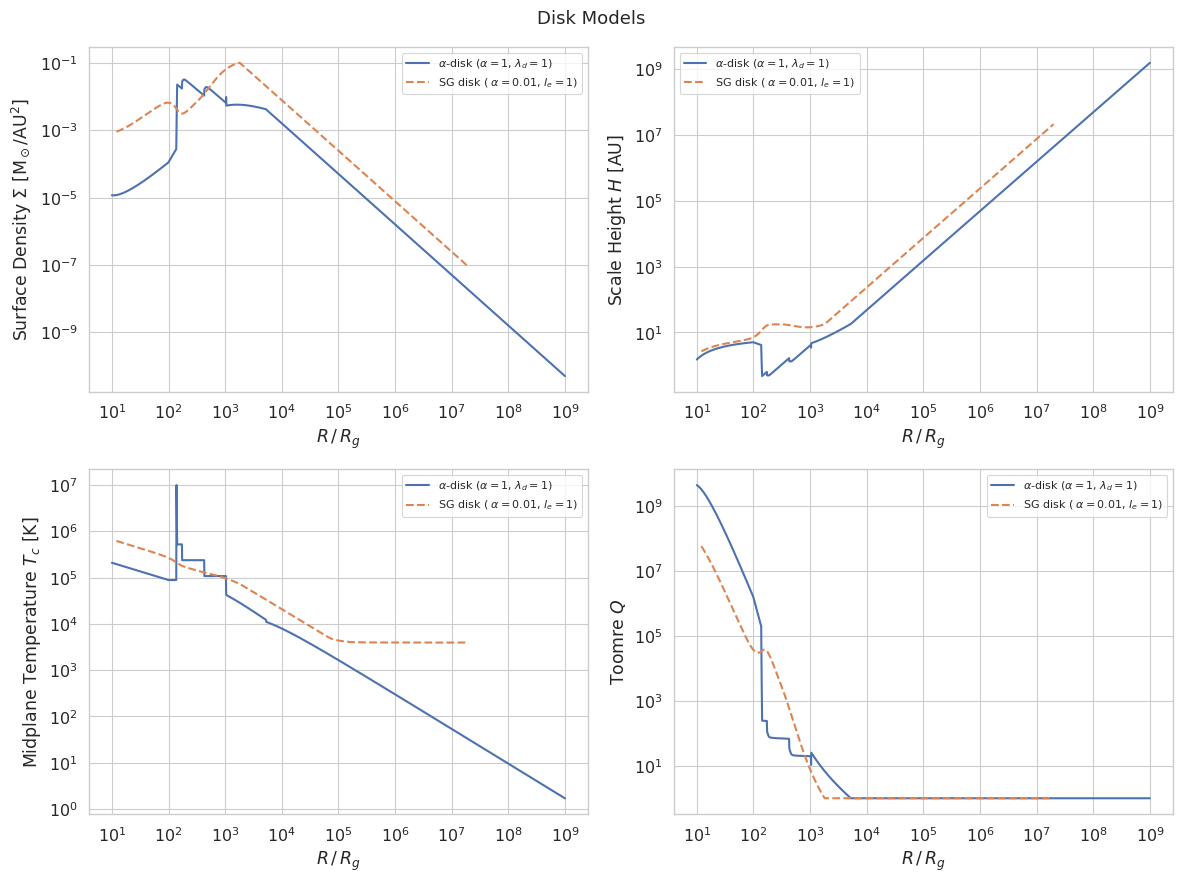

In [37]:
sns.set_style("whitegrid")

quantities = [
    ("Sigma", r"Surface Density $\Sigma$ [M$_\odot$/AU$^2$]"),
    ("H",     r"Scale Height $H$ [AU]"),
    ("Tc",    r"Midplane Temperature $T_c$ [K]"),
    ("Q",     r"Toomre $Q$"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (col, ylabel) in zip(axes.flat, quantities):
    ax.loglog(df_alpha["R/Rg"], df_alpha[col],
              label=r"$\alpha$-disk ($\alpha=1$, $\lambda_d=1$)", lw=1.5)
    ax.loglog(df_pagn["R/Rg"],  df_pagn[col],
              label=r"SG disk ( $\alpha=0.01$, $l_e=1$)", lw=1.5, ls="--")
    ax.set_xlabel(r"$R\,/\,R_g$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

fig.suptitle("Disk Models", fontsize=13)
plt.tight_layout()
plt.show()

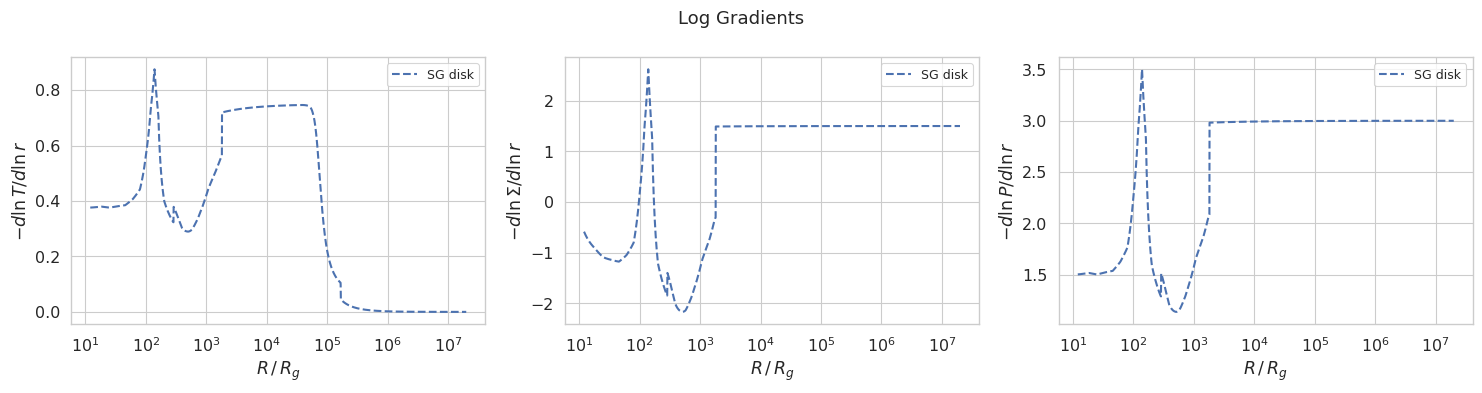

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

grad_panels = [
    ("grad_T",     r"$-d\ln T / d\ln r$"),
    ("grad_Sigma", r"$-d\ln \Sigma / d\ln r$"),
    ("grad_P",     r"$-d\ln P / d\ln r$"),
]

for ax, (col, ylabel) in zip(axes, grad_panels):
    #ax.plot(df_alpha["R/Rg"], df_alpha[col], label=r"$\alpha$-disk", lw=1.5)
    ax.plot(df_pagn["R/Rg"],  df_pagn[col],
            label="SG disk", lw=1.5, ls="--")
    ax.set_xscale("log")
    ax.set_xlabel(r"$R\,/\,R_g$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

fig.suptitle("Log Gradients", fontsize=13)
plt.tight_layout()
plt.show()

Zone boundary: index 1751,  R/Rg = 1814.2
grad_P jump:  2.0860 → 2.9815  (42.9%)

Spline: 2 knots  log₁₀(R/Rg) ∈ [1.08, 7.30]
  first 5 knots: [1.08 7.3 ]
  last  5 knots: [1.08 7.3 ]

Gap-fill (linear): anchors y0=1.8263 → y1=2.9841  (gap indices [1651, 1851), 200 pts)
Gap-fill (cubic Hermite): dy0=1.8425, dy1=0.0177


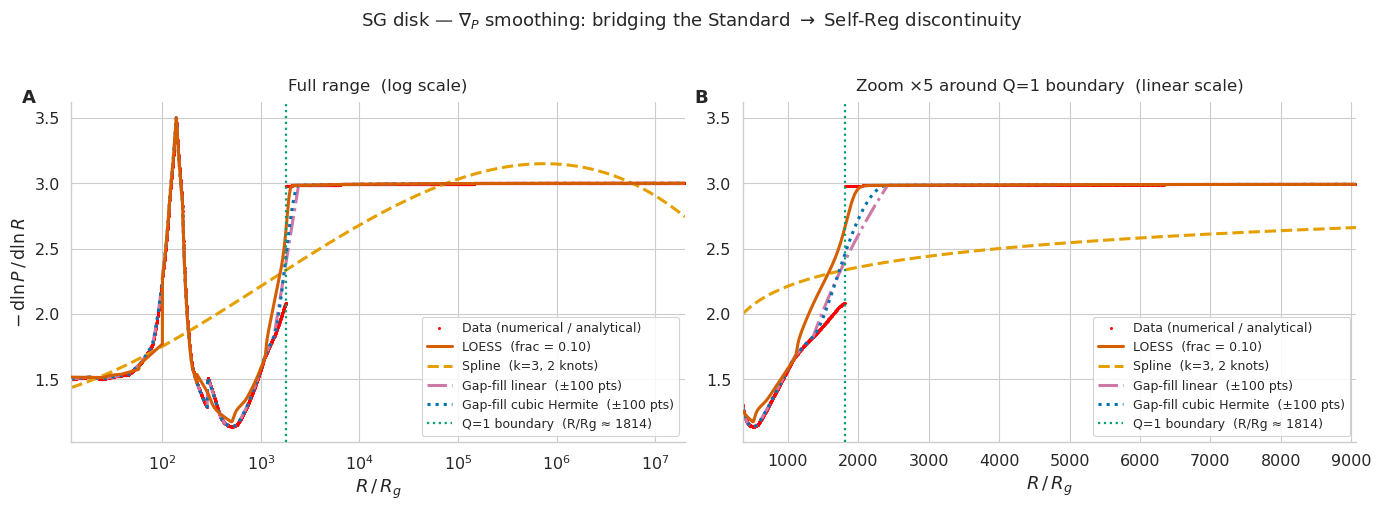

In [43]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import UnivariateSpline, CubicHermiteSpline

# Okabe-Ito colorblind-safe palette
OKABE = {
    "data":         "#56B4E9",   # sky blue
    "loess":        "#D55E00",   # vermillion
    "spline":       "#E69F00",   # orange
    "gapfill":      "#CC79A7",   # pink/purple
    "gapfill-poly": "#0072B2",   # blue
    "bnd":          "#009E73",   # teal (Q=1 boundary)
}

# ── Data: df_pagn has the Q=1 zone boundary (43% grad_P jump at index 1751) ──
log_R  = np.log10(df_pagn["R/Rg"].values)
grad_P = df_pagn["grad_P"].values
zone   = df_pagn["zone"].values

# Zone boundary: first Self-Reg row
ibnd  = np.where(zone == "Self-Reg")[0][0]
R_bnd = df_pagn["R/Rg"].iloc[ibnd]

print(f"Zone boundary: index {ibnd},  R/Rg = {R_bnd:.1f}")
print(f"grad_P jump:  {grad_P[ibnd-1]:.4f} → {grad_P[ibnd]:.4f}  "
      f"({abs(grad_P[ibnd]-grad_P[ibnd-1])/grad_P[ibnd-1]*100:.1f}%)")

# ── 1. LOESS smooth ────────────────────────────────────────────────────────
# frac=0.10 → ~500 neighbours on 5000-point grid; wide enough to bridge the jump
_loess       = lowess(grad_P, log_R, frac=0.1, return_sorted=True)
log_R_loess  = _loess[:, 0]
grad_P_loess = _loess[:, 1]

# ── 2. Smoothing cubic spline (C++ portable) ────────────────────────────────
# UnivariateSpline finds a minimal set of B-spline knots (piecewise cubic).
# C++ implementation: gsl_spline_alloc(gsl_interp_cspline) or equivalent —
# just store knot positions and coefficients.
spl        = UnivariateSpline(log_R, grad_P, k=3, s=5 * len(log_R))
log_R_fine = np.linspace(log_R.min(), log_R.max(), 8000)
grad_P_spl = spl(log_R_fine)
knots      = spl.get_knots()

print(f"\nSpline: {len(knots)} knots  "
      f"log₁₀(R/Rg) ∈ [{log_R.min():.2f}, {log_R.max():.2f}]")
print(f"  first 5 knots: {np.round(knots[:5], 3)}")
print(f"  last  5 knots: {np.round(knots[-5:], 3)}")

# ── Shared gap geometry ────────────────────────────────────────────────────
n_gap = 100
i_lo  = ibnd - n_gap   # first removed index
i_hi  = ibnd + n_gap   # first kept index after gap

x0, y0 = log_R[i_lo - 1], grad_P[i_lo - 1]   # last Standard anchor
x1, y1 = log_R[i_hi],     grad_P[i_hi]         # first Self-Reg anchor

# ── 3. Gap-fill — linear interpolation ────────────────────────────────────
# Bridge with a straight line in log-R space. Trivially portable to C++.
grad_P_gapfill = grad_P.copy()
grad_P_gapfill[i_lo:i_hi] = np.interp(log_R[i_lo:i_hi], [x0, x1], [y0, y1])

print(f"\nGap-fill (linear): anchors y0={y0:.4f} → y1={y1:.4f}  "
      f"(gap indices [{i_lo}, {i_hi}), {2*n_gap} pts)")

# ── 4. Gap-fill — cubic Hermite interpolation ──────────────────────────────
# Same gap, but matches both value and first derivative at each anchor →
# C¹ continuity at the join.  Derivatives estimated from 5-point windows
# just outside the gap (avoids the noisy one-sided edge rows).
w    = 100
dy0  = np.mean(np.gradient(grad_P[i_lo-w-1 : i_lo], log_R[i_lo-w-1 : i_lo]))
dy1  = np.mean(np.gradient(grad_P[i_hi     : i_hi+w+1], log_R[i_hi : i_hi+w+1]))

chs             = CubicHermiteSpline([x0, x1], [y0, y1], [dy0, dy1])
grad_P_gapfill_poly        = grad_P.copy()
grad_P_gapfill_poly[i_lo:i_hi] = chs(log_R[i_lo:i_hi])

print(f"Gap-fill (cubic Hermite): dy0={dy0:.4f}, dy1={dy1:.4f}")

# ── 5. Two-panel comparison plot ───────────────────────────────────────────
# Panel A — full log-scale range (global structure)
# Panel B — linear-scale zoom ×5 around Q=1 boundary (local discontinuity)
zoom_lo = R_bnd / 5
zoom_hi = R_bnd * 5

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

panel_specs = [
    (axes[0], "log",    (df_pagn["R/Rg"].min(), df_pagn["R/Rg"].max()),
                         "Full range  (log scale)"),
    (axes[1], "linear", (zoom_lo, zoom_hi),
                         f"Zoom ×5 around Q=1 boundary  (linear scale)"),
]

for ax, xscale, xlim, title in panel_specs:
    ax.scatter(df_pagn["R/Rg"], grad_P,
               s=2, alpha=0.9, color="red", rasterized=True,
               label="Data (numerical / analytical)", zorder=1)
    ax.plot(10**log_R_loess, grad_P_loess,
            color=OKABE["loess"], lw=2.2,
            label="LOESS  (frac = 0.10)", zorder=3)
    ax.plot(10**log_R_fine, grad_P_spl,
            color=OKABE["spline"], lw=2.2, ls="--",
            label=f"Spline  (k=3, {len(knots)} knots)", zorder=2)
    ax.plot(df_pagn["R/Rg"], grad_P_gapfill,
            color=OKABE["gapfill"], lw=2.2, ls="-.",
            label=f"Gap-fill linear  (±{n_gap} pts)", zorder=2)
    ax.plot(df_pagn["R/Rg"], grad_P_gapfill_poly,
            color=OKABE["gapfill-poly"], lw=2.2, ls=":",
            label=f"Gap-fill cubic Hermite  (±{n_gap} pts)", zorder=2)
    ax.axvline(R_bnd, color=OKABE["bnd"], ls=":", lw=1.6,
               label=f"Q=1 boundary  (R/Rg ≈ {R_bnd:.0f})", zorder=4)

    ax.set_xscale(xscale)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"$R\,/\,R_g$", fontsize=13)
    ax.set_ylabel(r"$-\,\mathrm{d}\ln P\,/\,\mathrm{d}\ln R$" if ax is axes[0] else "")
    ax.set_title(title, fontsize=12, pad=8)
    ax.legend(fontsize=9, framealpha=0.85, handlelength=2.0)
    label = "A" if ax is axes[0] else "B"
    ax.text(-0.08, 1.04, label, transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="top")

sns.despine()
fig.suptitle(
    r"SG disk — $\nabla_P$ smoothing: bridging the Standard $\to$ Self-Reg discontinuity",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Validation: CubicHermiteSpline boundary smoothing ─────────────────────
# Compares smoothed vs original grad_P and grad_Sigma for:
#   (A/B) disktab model  α = 0.1  (generated here via the updated spacehub_pretab)
#   (C/D) pagn   model  α = 0.01  (df_pagn already in memory; smoothing re-applied)
#
# disk-model.hpp compatibility: C++ reads 13 columns by position and stops at
# grad_P; the _raw columns placed after 'zone' are never parsed → no hpp changes.

# ── 1. Disktab α = 0.1 ────────────────────────────────────────────────────
from disktab import AGNDisk as _AGNDisk

M01        = 1e8 * u.Msun
L_edd01    = 1.26e38 * (M01 / u.Msun) * u.erg / u.s
Mdot_edd01 = L_edd01 / (0.1 * c * c)

disk01       = _AGNDisk()
disk01.M     = M01
disk01.alpha = 0.1
disk01.Mdot  = 1.0 * Mdot_edd01

import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    df_disk01 = disk01.spacehub_pretab(rvals=np.logspace(1, 9, 2000))
for w_ in caught:
    print(w_.message)

print(f"\ndisktab α=0.1: {len(df_disk01)} rows  |  "
      f"zones: {df_disk01['zone'].value_counts().to_dict()}")
print(f"  raw gradients stored: {'grad_P_raw' in df_disk01.columns}")

# ── 2. Pagn α = 0.01 — apply same smoothing to a copy of df_pagn ──────────
from scipy.interpolate import CubicHermiteSpline as _CHS

def _apply_smooth(df, n_gap=100, w=100):
    """Mirror of _smooth_zone_gradients for use in the notebook."""
    df = df.copy()
    sr_idx = np.where(df['zone'].values == 'Self-Reg')[0]
    if len(sr_idx) == 0:
        return df
    ibnd  = int(sr_idx[0])
    log_R = np.log10(df['R/Rg'].values)
    N, i_lo, i_hi = len(df), ibnd - n_gap, ibnd + n_gap
    if i_lo <= w or i_hi + w >= N:
        print("Warning: window out of range; skipping."); return df
    for col in ('grad_P', 'grad_Sigma'):
        y = df[col].values.copy()
        df[f'{col}_raw'] = y.copy()
        x0, y0 = log_R[i_lo-1], y[i_lo-1]
        x1, y1 = log_R[i_hi],   y[i_hi]
        dy0 = np.mean(np.gradient(y[i_lo-w-1 : i_lo],      log_R[i_lo-w-1 : i_lo]))
        dy1 = np.mean(np.gradient(y[i_hi     : i_hi+w+1],  log_R[i_hi : i_hi+w+1]))
        chs = _CHS([x0, x1], [y0, y1], [dy0, dy1])
        y[i_lo:i_hi] = chs(log_R[i_lo:i_hi])
        df[col] = y
    return df

df_pagn_v = _apply_smooth(df_pagn, n_gap=100, w=100)
print(f"\npagn α=0.01: smoothing applied to copy of df_pagn  ({len(df_pagn_v)} rows)")

# ── 3. Four-panel validation plot ──────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

COL_ORIG = "#E24A33"   # vermillion — original (discontinuous)
COL_SMTH = "#0072B2"   # blue       — smoothed

panels = [
    (df_disk01,  r"disktab  ($\alpha=0.1$)",  axes[0, 0], axes[0, 1]),
    (df_pagn_v,  r"pagn  ($\alpha=0.01$)",    axes[1, 0], axes[1, 1]),
]

for df_v, model_label, ax_gP, ax_gS in panels:
    sr = np.where(df_v['zone'].values == 'Self-Reg')[0]
    R_bnd_v = df_v['R/Rg'].iloc[sr[0]] if len(sr) else None

    for ax, gcol, ylabel in [
        (ax_gP, 'grad_P',     r"$-\,d\ln P\,/\,d\ln R$"),
        (ax_gS, 'grad_Sigma', r"$-\,d\ln \Sigma\,/\,d\ln R$"),
    ]:
        raw = f'{gcol}_raw'
        if raw in df_v.columns:
            ax.plot(df_v['R/Rg'], df_v[raw],
                    color=COL_ORIG, lw=1.5, alpha=0.55,
                    label="Original (discontinuous)")
        ax.plot(df_v['R/Rg'], df_v[gcol],
                color=COL_SMTH, lw=2.2,
                label="Smoothed  (cubic Hermite)")
        if R_bnd_v is not None:
            ax.axvline(R_bnd_v, color="#009E73", ls=":", lw=1.4,
                       label=f"Q=1  (R/Rg≈{R_bnd_v:.0f})")
        ax.set_xscale("log")
        ax.set_xlabel(r"$R\,/\,R_g$")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{model_label}  —  {ylabel}", fontsize=11)
        ax.legend(fontsize=9, framealpha=0.85)

for ax, lbl in zip(axes.flat, ["A", "B", "C", "D"]):
    ax.text(-0.07, 1.04, lbl, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top')

sns.despine()
fig.suptitle(
    r"Validation: CubicHermiteSpline boundary smoothing  ($n_\mathrm{gap}=100,\;w=100$)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Validation

### Required CSV format (`disk-model.hpp`)
14 columns in order: `R, R/Rg, Tc, rho, P, cs, H, visc, Sigma, Q, grad_T, grad_Sigma, grad_P, zone`

Key invariants that both CSVs must satisfy:
- `R` is monotonically increasing
- No NaN or non-positive values in: `R, rho, P, cs, H, Sigma, Q`
- Zone labels are only `"Standard"` or `"Self-Reg"`, with Standard rows before Self-Reg rows
- In Self-Reg zone: `Q ≈ 1.0` (within ±0.05)
- `grad_P` is finite everywhere

### Running the validator
After writing both CSVs, update `CSV_PATH` in the test script and run:
```bash
cd SpaceHub/test/verify_gas_drag/tests
python test_pagn_csv.py
```